In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.feature_extraction import DictVectorizer

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

In [4]:
import pickle

In [5]:
import mlflow
mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment('my-new-experiment')

<Experiment: artifact_location='/Users/julia/Desktop/Projects/mlops-zoomcamp-exercises/02-experiment-tracking/mlruns/2', creation_time=1779685780232, experiment_id='2', last_update_time=1779685780232, lifecycle_stage='active', name='my-new-experiment', tags={}, trace_location=None, workspace='default'>

In [6]:
filename = 'https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2021-01.parquet'

In [7]:
df = pd.read_parquet(
    'https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2021-01.parquet'
)


In [8]:
df

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
0,2,2021-01-01 00:15:56,2021-01-01 00:19:52,N,1.0,43,151,1.0,1.01,5.50,0.50,0.5,0.00,0.00,None,0.3,6.80,2.0,1.0,0.00
1,2,2021-01-01 00:25:59,2021-01-01 00:34:44,N,1.0,166,239,1.0,2.53,10.00,0.50,0.5,2.81,0.00,None,0.3,16.86,1.0,1.0,2.75
2,2,2021-01-01 00:45:57,2021-01-01 00:51:55,N,1.0,41,42,1.0,1.12,6.00,0.50,0.5,1.00,0.00,None,0.3,8.30,1.0,1.0,0.00
3,2,2020-12-31 23:57:51,2021-01-01 00:04:56,N,1.0,168,75,1.0,1.99,8.00,0.50,0.5,0.00,0.00,None,0.3,9.30,2.0,1.0,0.00
4,2,2021-01-01 00:16:36,2021-01-01 00:16:40,N,2.0,265,265,3.0,0.00,-52.00,0.00,-0.5,0.00,0.00,None,-0.3,-52.80,3.0,1.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76513,2,2021-01-31 21:38:00,2021-01-31 22:16:00,None,NaN,81,90,NaN,17.63,56.23,2.75,0.0,0.00,6.12,None,0.3,65.40,NaN,NaN,NaN
76514,2,2021-01-31 22:43:00,2021-01-31 23:21:00,None,NaN,35,213,NaN,18.36,46.66,0.00,0.0,12.20,6.12,None,0.3,65.28,NaN,NaN,NaN
76515,2,2021-01-31 22:16:00,2021-01-31 22:27:00,None,NaN,74,69,NaN,2.50,18.95,2.75,0.0,0.00,0.00,None,0.3,22.00,NaN,NaN,NaN
76516,2,2021-01-31 23:10:00,2021-01-31 23:37:00,None,NaN,168,215,NaN,14.48,48.87,2.75,0.0,0.00,6.12,None,0.3,58.04,NaN,NaN,NaN


In [9]:
df.dtypes

VendorID                          int64
lpep_pickup_datetime     datetime64[us]
lpep_dropoff_datetime    datetime64[us]
store_and_fwd_flag               object
RatecodeID                      float64
PULocationID                      int64
DOLocationID                      int64
passenger_count                 float64
trip_distance                   float64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
ehail_fee                        object
improvement_surcharge           float64
total_amount                    float64
payment_type                    float64
trip_type                       float64
congestion_surcharge            float64
dtype: object

In [10]:
df.trip_type.value_counts()

trip_type
1.0    39233
2.0     1238
Name: count, dtype: int64

In [11]:
df_filtered = df[df.trip_type == 2]
df_filtered.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
6,2,2021-01-01 00:19:14,2021-01-01 00:19:21,N,5.0,265,265,1.0,0.00,180.0,0.0,0.0,36.06,0.0,None,0.3,216.36,1.0,2.0,0.0
15,2,2021-01-01 00:29:05,2021-01-01 00:29:07,N,5.0,42,264,1.0,0.00,10.0,0.0,0.0,2.06,0.0,None,0.3,12.36,1.0,2.0,0.0
30,2,2021-01-01 00:35:29,2021-01-01 00:55:15,N,5.0,74,247,1.0,3.64,13.0,0.0,0.0,0.00,0.0,None,0.3,13.30,2.0,2.0,0.0
43,2,2021-01-01 23:12:41,2021-01-02 01:13:53,N,5.0,95,82,1.0,0.00,9.7,0.0,0.0,2.00,0.0,None,0.3,12.00,1.0,2.0,0.0
45,2,2021-01-01 01:49:29,2021-01-01 01:49:33,N,5.0,244,244,5.0,0.02,12.0,0.0,0.0,2.46,0.0,None,0.3,14.76,1.0,2.0,0.0


In [12]:
df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)
df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)

In [13]:
df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

In [14]:
df

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,duration
0,2,2021-01-01 00:15:56,2021-01-01 00:19:52,N,1.0,43,151,1.0,1.01,5.50,...,0.5,0.00,0.00,None,0.3,6.80,2.0,1.0,0.00,3.933333
1,2,2021-01-01 00:25:59,2021-01-01 00:34:44,N,1.0,166,239,1.0,2.53,10.00,...,0.5,2.81,0.00,None,0.3,16.86,1.0,1.0,2.75,8.750000
2,2,2021-01-01 00:45:57,2021-01-01 00:51:55,N,1.0,41,42,1.0,1.12,6.00,...,0.5,1.00,0.00,None,0.3,8.30,1.0,1.0,0.00,5.966667
3,2,2020-12-31 23:57:51,2021-01-01 00:04:56,N,1.0,168,75,1.0,1.99,8.00,...,0.5,0.00,0.00,None,0.3,9.30,2.0,1.0,0.00,7.083333
4,2,2021-01-01 00:16:36,2021-01-01 00:16:40,N,2.0,265,265,3.0,0.00,-52.00,...,-0.5,0.00,0.00,None,-0.3,-52.80,3.0,1.0,0.00,0.066667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76513,2,2021-01-31 21:38:00,2021-01-31 22:16:00,None,NaN,81,90,NaN,17.63,56.23,...,0.0,0.00,6.12,None,0.3,65.40,NaN,NaN,NaN,38.000000
76514,2,2021-01-31 22:43:00,2021-01-31 23:21:00,None,NaN,35,213,NaN,18.36,46.66,...,0.0,12.20,6.12,None,0.3,65.28,NaN,NaN,NaN,38.000000
76515,2,2021-01-31 22:16:00,2021-01-31 22:27:00,None,NaN,74,69,NaN,2.50,18.95,...,0.0,0.00,0.00,None,0.3,22.00,NaN,NaN,NaN,11.000000
76516,2,2021-01-31 23:10:00,2021-01-31 23:37:00,None,NaN,168,215,NaN,14.48,48.87,...,0.0,0.00,6.12,None,0.3,58.04,NaN,NaN,NaN,27.000000


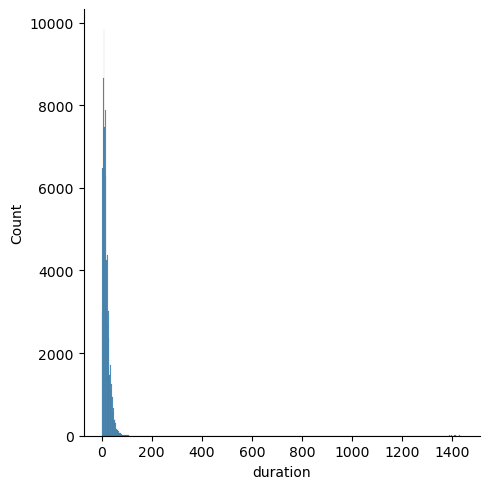

In [15]:
sns.displot(df.duration)

In [16]:
df.duration.describe(percentiles=[0.95, 0.98, 0.99])

count    76518.000000
mean        19.927896
std         59.338594
min          0.000000
50%         13.883333
95%         44.000000
98%         56.000000
99%         67.158167
max       1439.600000
Name: duration, dtype: float64

In [17]:
df = df[((df.duration >= 0) & (df.duration <= 120))]

In [18]:
df

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,duration
0,2,2021-01-01 00:15:56,2021-01-01 00:19:52,N,1.0,43,151,1.0,1.01,5.50,...,0.5,0.00,0.00,None,0.3,6.80,2.0,1.0,0.00,3.933333
1,2,2021-01-01 00:25:59,2021-01-01 00:34:44,N,1.0,166,239,1.0,2.53,10.00,...,0.5,2.81,0.00,None,0.3,16.86,1.0,1.0,2.75,8.750000
2,2,2021-01-01 00:45:57,2021-01-01 00:51:55,N,1.0,41,42,1.0,1.12,6.00,...,0.5,1.00,0.00,None,0.3,8.30,1.0,1.0,0.00,5.966667
3,2,2020-12-31 23:57:51,2021-01-01 00:04:56,N,1.0,168,75,1.0,1.99,8.00,...,0.5,0.00,0.00,None,0.3,9.30,2.0,1.0,0.00,7.083333
4,2,2021-01-01 00:16:36,2021-01-01 00:16:40,N,2.0,265,265,3.0,0.00,-52.00,...,-0.5,0.00,0.00,None,-0.3,-52.80,3.0,1.0,0.00,0.066667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76513,2,2021-01-31 21:38:00,2021-01-31 22:16:00,None,NaN,81,90,NaN,17.63,56.23,...,0.0,0.00,6.12,None,0.3,65.40,NaN,NaN,NaN,38.000000
76514,2,2021-01-31 22:43:00,2021-01-31 23:21:00,None,NaN,35,213,NaN,18.36,46.66,...,0.0,12.20,6.12,None,0.3,65.28,NaN,NaN,NaN,38.000000
76515,2,2021-01-31 22:16:00,2021-01-31 22:27:00,None,NaN,74,69,NaN,2.50,18.95,...,0.0,0.00,0.00,None,0.3,22.00,NaN,NaN,NaN,11.000000
76516,2,2021-01-31 23:10:00,2021-01-31 23:37:00,None,NaN,168,215,NaN,14.48,48.87,...,0.0,0.00,6.12,None,0.3,58.04,NaN,NaN,NaN,27.000000


In [19]:
# df_train ['PU_DO'] = df_train['PULocationID'] + '_' + df_train['DOLocationID'] 
# df_val ['PU_DO'] = df_val['PULocationID'] + '_' + df_val['DOLocationID'] 

In [20]:
# df_val

In [21]:
categorical = ['PULocationID', 'DOLocationID']
numerical = ['trip_distance']

In [22]:
df[categorical] = df[categorical].astype(str)

/var/folders/gk/87pgnywd0yj8v_zr8sbrmdd40000gn/T/ipykernel_58414/1767203464.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[categorical] = df[categorical].astype(str)


In [23]:
train_dicts = df[categorical + numerical].to_dict(orient='records')

dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)

target = 'duration'
y_train = df[target].values

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_train)

mean_squared_error(y_train, y_pred)
import os
import pickle

os.makedirs("preprocessor", exist_ok=True)

with open("preprocessor/preprocessor.b", "wb") as f_out:
    pickle.dump(dv, f_out)

mlflow.log_artifact(
    local_path="preprocessor/preprocessor.b",
    artifact_path="preprocessor"
)

/var/folders/gk/87pgnywd0yj8v_zr8sbrmdd40000gn/T/ipykernel_58414/1505421196.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_pred, label='prediction')
/var/folders/gk/87pgnywd0yj8v_zr8sbrmdd40000gn/T/ipykernel_58414/1505421196.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_train, lab

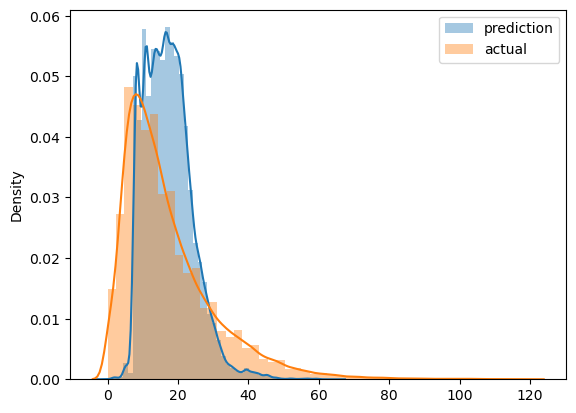

In [24]:
sns.distplot(y_pred, label='prediction')
sns.distplot(y_train, label='actual')
plt.legend()

In [25]:
def read_dataframe(filename): 
    df = pd.read_parquet(filename)
    df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)
    df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)
    
    df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
    df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)
    
    df = df[((df.duration >= 0) & (df.duration <= 120))]
    
    categorical = ['PULocationID', 'DOLocationID']
    # numerical = ['trip_distance']
    df[categorical] = df[categorical].astype(str)

    return df

In [26]:
df_train = read_dataframe('https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2021-01.parquet')
df_val = read_dataframe('https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2021-02.parquet')

In [27]:
len(df_train), len(df_val)

(76301, 64361)

In [28]:
df_train ['PU_DO'] = df_train['PULocationID'] + '_' + df_train['DOLocationID'] 
df_val ['PU_DO'] = df_val['PULocationID'] + '_' + df_val['DOLocationID'] 

In [29]:
categorical = ['PU_DO'] 
    # ['PULocationID', 'DOLocationID']
numerical = ['trip_distance']

dv = DictVectorizer()
# X_train = dv.fit_transform(train_dicts)
train_dicts = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts =  df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [30]:
target = 'duration'
y_train = df_train[target].values
y_val = df_val[target].values

In [31]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

mean_squared_error(y_val, y_pred)

96.09284397426069

In [32]:
lr = Lasso(alpha=0.001)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

mean_squared_error(y_val, y_pred)

128.602034202059

In [33]:
lr = Ridge()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

mean_squared_error(y_val, y_pred)

94.39750166653943

In [34]:
import os
os.makedirs('../models', exist_ok=True)
with open('../models/lin_reg.bin', 'wb') as f_out:
          pickle.dump((dv, lr), f_out)

In [36]:
with mlflow.start_run(nested=True):
    import os
    print(os.getcwd())
    
    mlflow.set_tag('dev', 'jj')
    mlflow.log_param('train data', 'https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2021-01.parquet')
    mlflow.log_param('valid data', 'https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2021-02.parquet')

    alpha=0.001
    mlflow.log_param('alpha', alpha)

    lr = Lasso(alpha)
    lr.fit(X_train, y_train)
    
    y_pred = lr.predict(X_val)
    
    rmse = mean_squared_error(y_val, y_pred)
    mlflow.log_metric("rmse", rmse)

    mlflow.log_artifact(local_path='../models/lin_reg.bin', artifact_path='models_pickle')

/Users/julia/Desktop/Projects/mlops-zoomcamp-exercises/02-experiment-tracking


In [37]:
import xgboost as xgb


In [38]:
import sys
print(sys.executable)

/Users/julia/miniforge3/envs/mlops_bootcamp/bin/python


In [39]:
!{sys.executable} -m pip install "setuptools<81"

In [40]:
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from hyperopt.pyll import scope

/Users/julia/miniforge3/envs/mlops_bootcamp/lib/python3.13/site-packages/hyperopt/atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [41]:
def objective(params):
    with mlflow.start_run():
        mlflow.set_tag("model", "xgboost")
        mlflow.log_params(params)
        booster = xgb.train(
            params=params,
            dtrain=train,
            num_boost_round=1000,
            evals=[(valid, 'validation')],
            early_stopping_rounds=50
        )
        y_pred = booster.predict(valid)
        rmse = mean_squared_error(y_val, y_pred)
        mlflow.log_metric("rmse", rmse)

    return {'loss': rmse, 'status': STATUS_OK}

In [42]:
train = xgb.DMatrix(X_train, label=y_train)
valid = xgb.DMatrix(X_val, label=y_val)

In [43]:
search_space = {
    'max_depth': scope.int(hp.quniform('max_depth', 4, 100, 1)),
    'learning_rate': hp.loguniform('learning_rate', -3, 0),
    'reg_alpha': hp.loguniform('reg_alpha', -5, -1),
    'reg_lambda': hp.loguniform('reg_lambda', -6, -1),
    'min_child_weight': hp.loguniform('min_child_weight', -1, 3),
    'objective': 'reg:linear',
    'seed': 42
}

best_result = fmin(
    fn=objective,
    space=search_space,
    algo=tpe.suggest,
    max_evals=50,
    trials=Trials()
)

  0%|          | 0/50 [00:00<?, ?trial/s, best loss=?]

job exception: Run with UUID 11b501bb9d3845389d1d65bf73a03e29 is already active. To start a new run, first end the current run with mlflow.end_run(). To start a nested run, call start_run with nested=True



  0%|          | 0/50 [00:00<?, ?trial/s, best loss=?]


Exception: Run with UUID 11b501bb9d3845389d1d65bf73a03e29 is already active. To start a new run, first end the current run with mlflow.end_run(). To start a nested run, call start_run with nested=True

In [ ]:
params = {
'learning_rate': 0.23663837413933345,
'max_depth': 63,
'min_child_weight': 5.145379319889727,
'objective': 'reg:linear',
'reg_alpha': 0.011421312210525376,
'reg_lambda': 0.365514542783101,
'seed': 42
}

In [ ]:
mlflow.xgboost.autolog(disable=True)
booster = xgb.train(
    params=params,
    dtrain=train,
    num_boost_round=1000,
    evals=[(valid, 'validation')],
    early_stopping_rounds=50
)

[0]	validation-rmse:12.58058


/Users/julia/miniforge3/envs/mlops_bootcamp/lib/python3.13/site-packages/xgboost/callback.py:385: UserWarning: [19:23:34] WARNING: /Users/runner/work/xgboost/xgboost/src/objective/regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[1]	validation-rmse:11.14507
[2]	validation-rmse:10.17273
[3]	validation-rmse:9.52563
[4]	validation-rmse:9.10010
[5]	validation-rmse:8.81198
[6]	validation-rmse:8.61862
[7]	validation-rmse:8.48975
[8]	validation-rmse:8.39755
[9]	validation-rmse:8.33113
[10]	validation-rmse:8.28237
[11]	validation-rmse:8.24520
[12]	validation-rmse:8.21719
[13]	validation-rmse:8.19801
[14]	validation-rmse:8.18109
[15]	validation-rmse:8.16779
[16]	validation-rmse:8.15630
[17]	validation-rmse:8.14881
[18]	validation-rmse:8.14312
[19]	validation-rmse:8.13918
[20]	validation-rmse:8.13666
[21]	validation-rmse:8.13185
[22]	validation-rmse:8.13053
[23]	validation-rmse:8.12752
[24]	validation-rmse:8.12238
[25]	validation-rmse:8.12007
[26]	validation-rmse:8.11847
[27]	validation-rmse:8.11452
[28]	validation-rmse:8.11341
[29]	validation-rmse:8.11321
[30]	validation-rmse:8.11154
[31]	validation-rmse:8.10995
[32]	validation-rmse:8.10885
[33]	validation-rmse:8.10731
[34]	validation-rmse:8.10587
[35]	validation-rmse:

In [ ]:
with mlflow.start_run():
    best_params = {
        'learning_rate': 0.23663837413933345,
        'max_depth': 63,
        'min_child_weight': 5.145379319889727,
        'objective': 'reg:linear',
        'reg_alpha': 0.011421312210525376,
        'reg_lambda': 0.365514542783101,
        'seed': 42
    }
    mlflow.log_params(best_params)

    booster = xgb.train(
        params=params,
        dtrain=train,
        num_boost_round=1000,
        evals=[(valid, 'validation')],
        early_stopping_rounds=50
    )  
    y_pred = booster.predict(valid) 
    rmse = mean_squared_error(y_val, y_pred)
    
    mlflow.xgboost.log_model(booster, artifact_path='models_mlflow')
    # mlflow.log_artifact(local_path='../models/lin_reg.bin', artifact_path='models_pickle')

[0]	validation-rmse:12.58058


/Users/julia/miniforge3/envs/mlops_bootcamp/lib/python3.13/site-packages/xgboost/callback.py:385: UserWarning: [19:23:59] WARNING: /Users/runner/work/xgboost/xgboost/src/objective/regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[1]	validation-rmse:11.14507
[2]	validation-rmse:10.17273
[3]	validation-rmse:9.52563
[4]	validation-rmse:9.10010
[5]	validation-rmse:8.81198
[6]	validation-rmse:8.61862
[7]	validation-rmse:8.48975
[8]	validation-rmse:8.39755
[9]	validation-rmse:8.33113
[10]	validation-rmse:8.28237
[11]	validation-rmse:8.24520
[12]	validation-rmse:8.21719
[13]	validation-rmse:8.19801
[14]	validation-rmse:8.18109
[15]	validation-rmse:8.16779
[16]	validation-rmse:8.15630
[17]	validation-rmse:8.14881
[18]	validation-rmse:8.14312
[19]	validation-rmse:8.13918
[20]	validation-rmse:8.13666
[21]	validation-rmse:8.13185
[22]	validation-rmse:8.13053
[23]	validation-rmse:8.12752
[24]	validation-rmse:8.12238
[25]	validation-rmse:8.12007
[26]	validation-rmse:8.11847
[27]	validation-rmse:8.11452
[28]	validation-rmse:8.11341
[29]	validation-rmse:8.11321
[30]	validation-rmse:8.11154
[31]	validation-rmse:8.10995
[32]	validation-rmse:8.10885
[33]	validation-rmse:8.10731
[34]	validation-rmse:8.10587
[35]	validation-rmse:

2026/05/25 19:24:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [ ]:
import mlflow

logged_model = 'runs:/e20560ecbd23409cbb17d32899ae7435/models_mlflow'

loaded_model = mlflow.pyfunc.load_model(logged_model)

predictions = loaded_model.predict(X_val)

In [ ]:
loaded_model

mlflow.pyfunc.loaded_model:
  artifact_path: /Users/julia/Desktop/Projects/mlops-zoomcamp-exercises/02-experiment-tracking/mlruns/2/models/m-aff75da99c4241f5ac20285c5fc14099/artifacts
  flavor: mlflow.xgboost
  run_id: e20560ecbd23409cbb17d32899ae7435

In [ ]:
xboost_model = mlflow.xgboost.load_model(logged_model)

In [ ]:
xboost_model

In [ ]:
y_pred = xboost_model.predict(valid)

In [ ]:
y_pred

array([12.706115 ,  6.6982017, 14.229042 , ..., 13.610069 ,  6.078555 ,
        8.09891  ], shape=(64361,), dtype=float32)